IMPORTING LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

LOADING THE DATASET

In [3]:
file_path = r"D:\Thesis_Speed_Model\data\Raw\Final Data for Modeling.xlsx"
df = pd.read_excel(file_path)

In [4]:
df.head()

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type
0,1,57.0,1.27,inf,5.5,0.9,Gravel,0.9,Gravel
1,2,33.0,2.92,46.0,5.5,0.9,Gravel,0.9,Gravel
2,3,43.0,7.97,inf,5.5,0.9,Gravel,0.9,Gravel
3,4,48.0,2.07,inf,5.5,0.9,Gravel,0.9,Gravel
4,5,36.0,1.21,16.0,5.5,0.9,Gravel,0.9,Gravel


CHECKING THE DATASET SHAPE

In [5]:
df.shape

(140, 9)

SHOWING THE COLUMN NAMES

In [6]:
df.columns.tolist()

['SN',
 'V85 Speed',
 'Gradient',
 'Radius of Curve',
 'Carriageway Width',
 'Left Shoulder Width',
 'Left Shoulder Type',
 'Right Shoulder Width',
 'Right Shoulder Type']

CHECKING THE DATA INFO

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SN                    140 non-null    int64  
 1   V85 Speed             140 non-null    float64
 2   Gradient              140 non-null    float64
 3   Radius of Curve       140 non-null    float64
 4   Carriageway Width     140 non-null    float64
 5   Left Shoulder Width   140 non-null    float64
 6   Left Shoulder Type    140 non-null    str    
 7   Right Shoulder Width  140 non-null    float64
 8   Right Shoulder Type   140 non-null    str    
dtypes: float64(6), int64(1), str(2)
memory usage: 10.0 KB


CHECKING THE MISSING VALUES

In [8]:
df.isnull().sum()

SN                      0
V85 Speed               0
Gradient                0
Radius of Curve         0
Carriageway Width       0
Left Shoulder Width     0
Left Shoulder Type      0
Right Shoulder Width    0
Right Shoulder Type     0
dtype: int64

SUMMARY OF DESCRIPTIVE STATISTICS

In [9]:
df.describe()

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width
count,140.0000,140.000000,140.000000,140.0,140.000000,140.000000,140.000000
mean,70.5000,46.831786,3.872104,inf,6.257550,0.512214,0.521143
std,40.5586,10.353012,2.573637,NaN,0.936458,0.401510,0.394580
min,1.0000,24.000000,0.100000,15.0,4.700000,0.000000,0.000000
25%,35.7500,40.812500,1.387500,50.0,5.500000,0.000000,0.000000
50%,70.5000,46.000000,3.765000,120.0,7.000000,0.500000,0.500000
75%,105.2500,55.000000,5.985000,NaN,7.000000,0.900000,0.907500
max,140.0000,74.000000,10.000000,inf,8.000000,1.130000,1.180000


INSPECTING THE RADIUS VALUES

In [10]:
df["Radius of Curve"].head(20)

0       inf
1      46.0
2       inf
3       inf
4      16.0
5       inf
6     150.0
7       inf
8       inf
9      25.0
10      inf
11     80.0
12      inf
13    300.0
14      inf
15      inf
16      inf
17    300.0
18     80.0
19      inf
Name: Radius of Curve, dtype: float64

CHECKING THE INFINITY VALUES

In [11]:
np.isinf(df["Radius of Curve"]).sum()

np.int64(47)

RADIUS STATISTICS

In [12]:
df["Radius of Curve"].describe()

count    140.0
mean       inf
std        NaN
min       15.0
25%       50.0
50%      120.0
75%        NaN
max        inf
Name: Radius of Curve, dtype: float64

CREATING CURVATURE (1/R)

In [13]:
df["Curvature"] = np.where(np.isinf(df["Radius of Curve"]), 0, 1 / df["Radius of Curve"])

CHECKING CURVATURE VALUES

In [14]:
df[["Radius of Curve", "Curvature"]].head(20)

,Radius of Curve,Curvature
0,inf,0.000000
1,46.0,0.021739
2,inf,0.000000
3,inf,0.000000
4,16.0,0.062500
5,inf,0.000000
6,150.0,0.006667
7,inf,0.000000
8,inf,0.000000
9,25.0,0.040000


CURVATURE STATISTICS

In [15]:
df["Curvature"].describe()

count    140.000000
mean       0.014096
std        0.018046
min        0.000000
25%        0.000000
50%        0.008333
75%        0.020000
max        0.066667
Name: Curvature, dtype: float64

PLOT CURVE DISTRIBUTION

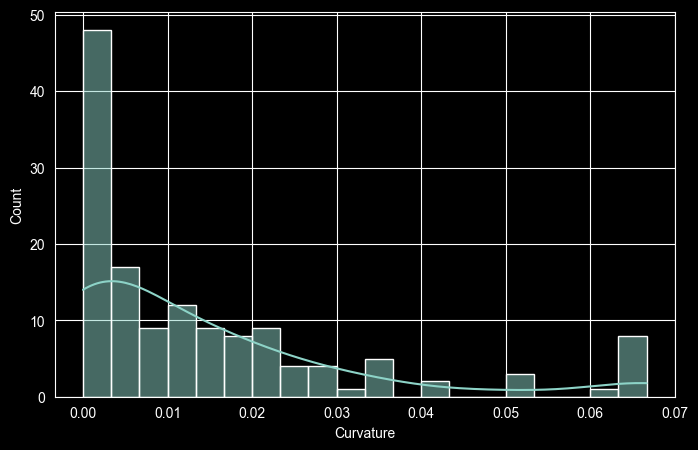

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["Curvature"], bins=20, kde=True)
plt.show()

In [17]:
df.describe()

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Curvature
count,140.0000,140.000000,140.000000,140.0,140.000000,140.000000,140.000000,140.000000
mean,70.5000,46.831786,3.872104,inf,6.257550,0.512214,0.521143,0.014096
std,40.5586,10.353012,2.573637,NaN,0.936458,0.401510,0.394580,0.018046
min,1.0000,24.000000,0.100000,15.0,4.700000,0.000000,0.000000,0.000000
25%,35.7500,40.812500,1.387500,50.0,5.500000,0.000000,0.000000,0.000000
50%,70.5000,46.000000,3.765000,120.0,7.000000,0.500000,0.500000,0.008333
75%,105.2500,55.000000,5.985000,NaN,7.000000,0.900000,0.907500,0.020000
max,140.0000,74.000000,10.000000,inf,8.000000,1.130000,1.180000,0.066667


DROP RADIUS COLUMN

In [18]:
df = df.drop(columns=["Radius of Curve"])

In [19]:
df.describe()

,SN,V85 Speed,Gradient,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Curvature
count,140.0000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,70.5000,46.831786,3.872104,6.257550,0.512214,0.521143,0.014096
std,40.5586,10.353012,2.573637,0.936458,0.401510,0.394580,0.018046
min,1.0000,24.000000,0.100000,4.700000,0.000000,0.000000,0.000000
25%,35.7500,40.812500,1.387500,5.500000,0.000000,0.000000,0.000000
50%,70.5000,46.000000,3.765000,7.000000,0.500000,0.500000,0.008333
75%,105.2500,55.000000,5.985000,7.000000,0.900000,0.907500,0.020000
max,140.0000,74.000000,10.000000,8.000000,1.130000,1.180000,0.066667


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SN                    140 non-null    int64  
 1   V85 Speed             140 non-null    float64
 2   Gradient              140 non-null    float64
 3   Carriageway Width     140 non-null    float64
 4   Left Shoulder Width   140 non-null    float64
 5   Left Shoulder Type    140 non-null    str    
 6   Right Shoulder Width  140 non-null    float64
 7   Right Shoulder Type   140 non-null    str    
 8   Curvature             140 non-null    float64
dtypes: float64(6), int64(1), str(2)
memory usage: 10.0 KB


In [21]:
df.head()

,SN,V85 Speed,Gradient,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type,Curvature
0,1,57.0,1.27,5.5,0.9,Gravel,0.9,Gravel,0.000000
1,2,33.0,2.92,5.5,0.9,Gravel,0.9,Gravel,0.021739
2,3,43.0,7.97,5.5,0.9,Gravel,0.9,Gravel,0.000000
3,4,48.0,2.07,5.5,0.9,Gravel,0.9,Gravel,0.000000
4,5,36.0,1.21,5.5,0.9,Gravel,0.9,Gravel,0.062500


DEFINING NUMERICAL COLUMNS

In [22]:
num_cols = [
    "V85 Speed",
    "Gradient",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "Curvature"
]

PLOTTING INDIVIDUAL HISTOGRAMS WITH KERNEL DENSITY ESTIMATE

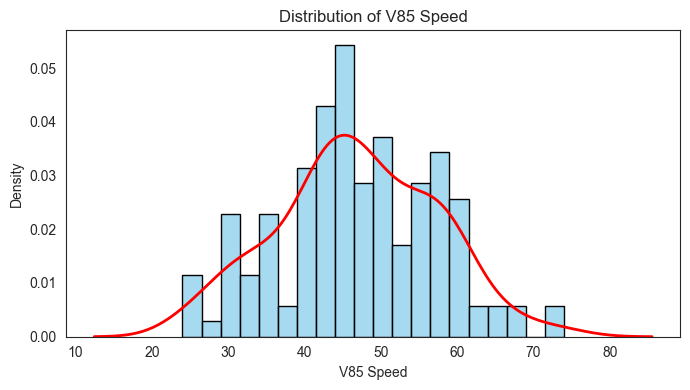

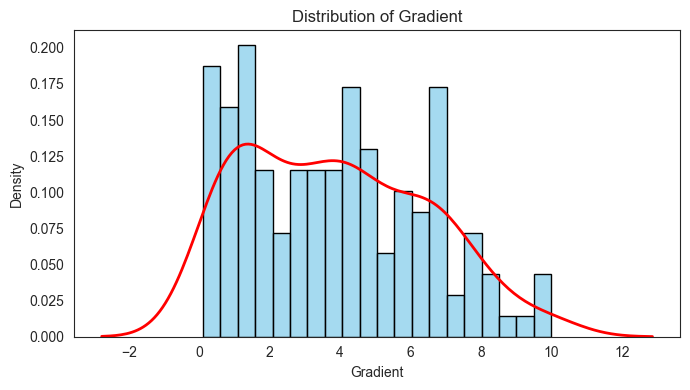

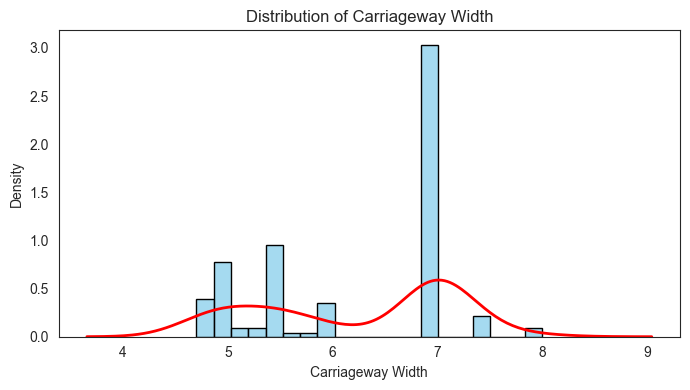

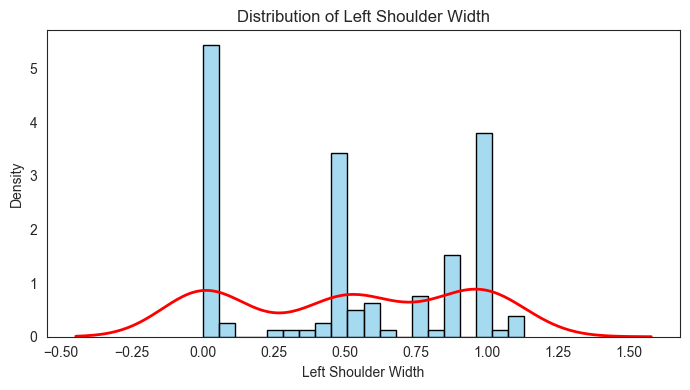

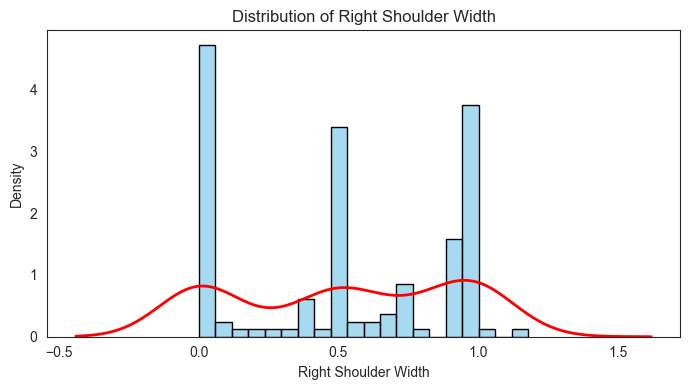

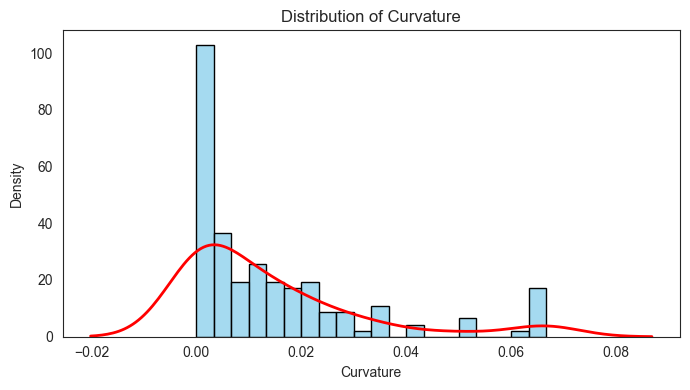

In [23]:
sns.set_style("white")

for col in num_cols:
    plt.figure(figsize=(7,4))

    sns.histplot(df[col], bins=20, stat="density", color="skyblue", edgecolor="black")
    sns.kdeplot(df[col], color="red", linewidth=2)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.tight_layout()
    plt.show()

INDIVIDUAL BOXPLOT

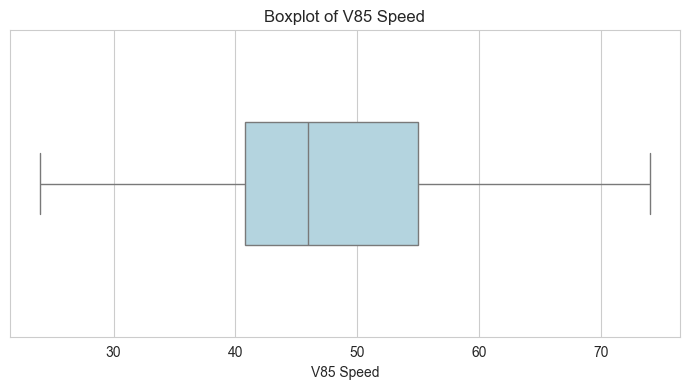

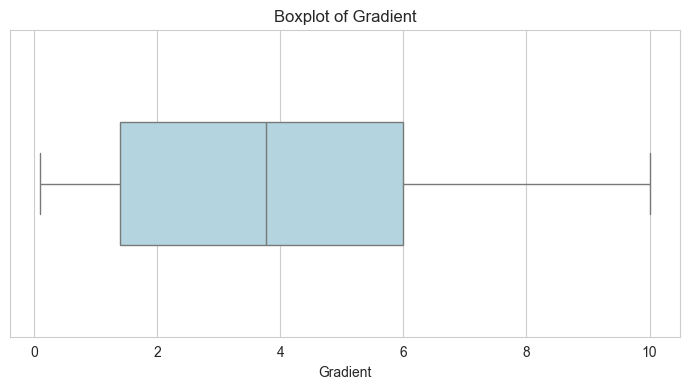

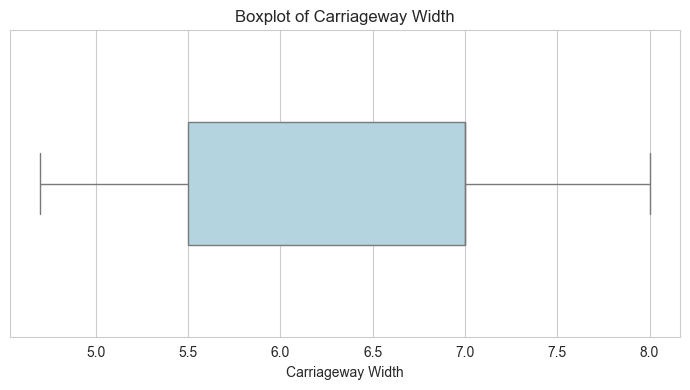

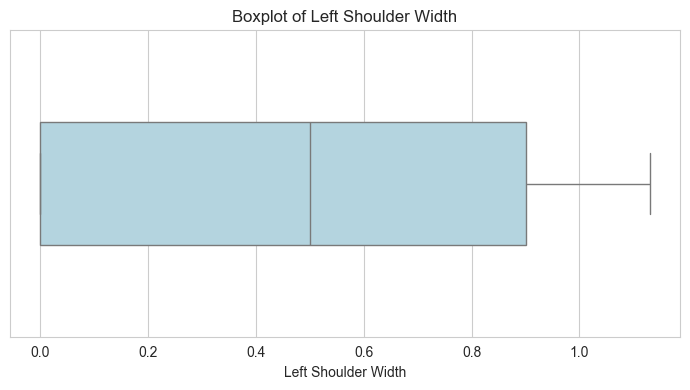

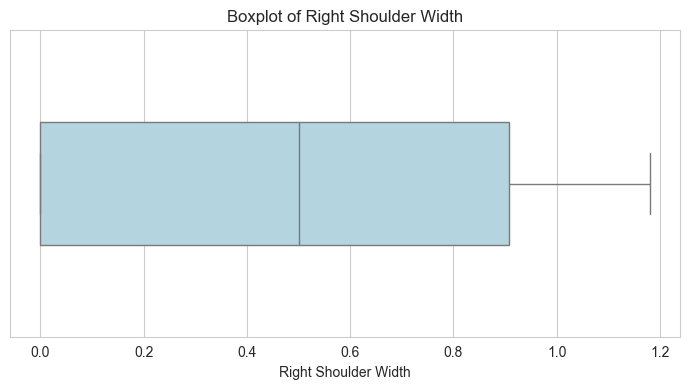

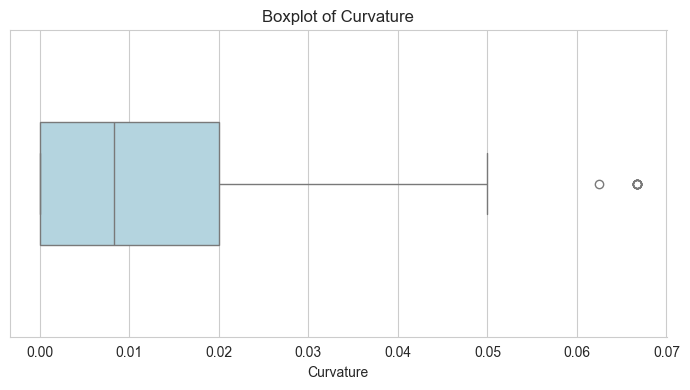

In [24]:
sns.set_style("whitegrid")

for col in num_cols:
    plt.figure(figsize=(7,4))

    sns.boxplot(x=df[col], color="lightblue", width=0.4)

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

COUNT PLOT OF SHOULDER TYPES

In [25]:
df["Left Shoulder Type"].unique()

<StringArray>
['Gravel', 'Paved ', 'Absent', 'Paved']
Length: 4, dtype: str

In [26]:
df["Left Shoulder Type"] = df["Left Shoulder Type"].str.strip().str.lower()
df["Right Shoulder Type"] = df["Right Shoulder Type"].str.strip().str.lower()

In [27]:
df["Left Shoulder Type"] = df["Left Shoulder Type"].str.capitalize()
df["Right Shoulder Type"] = df["Right Shoulder Type"].str.capitalize()

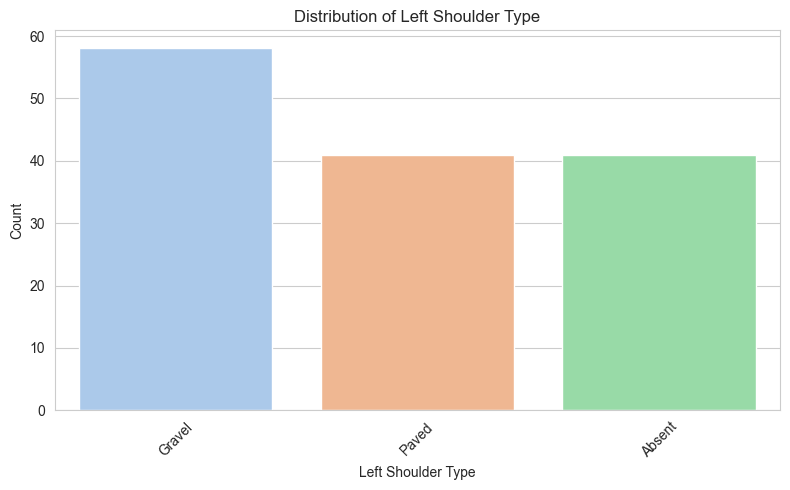

In [28]:
# Clean categorical values
df["Left Shoulder Type"] = df["Left Shoulder Type"].str.strip().str.lower().str.capitalize()

# Plot
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.countplot(x=df["Left Shoulder Type"], palette="pastel")

plt.xticks(rotation=45)
plt.title("Distribution of Left Shoulder Type")
plt.xlabel("Left Shoulder Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

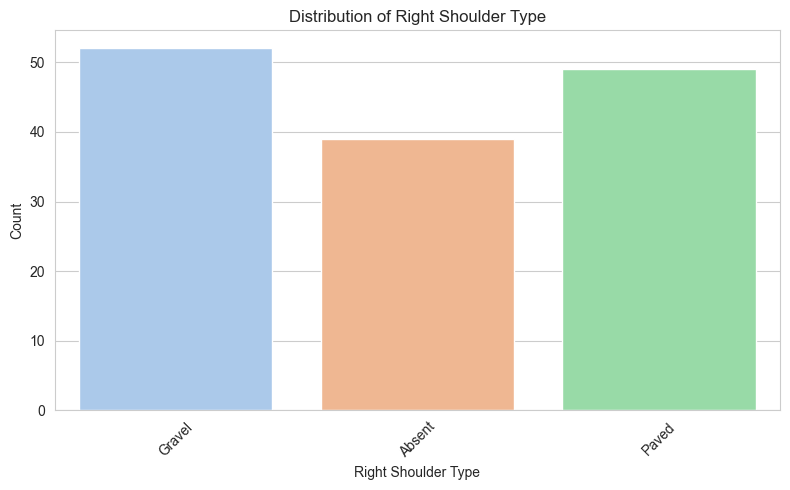

In [29]:
# Clean categorical values
df["Right Shoulder Type"] = df["Right Shoulder Type"].str.strip().str.lower().str.capitalize()

# Plot
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.countplot(x=df["Right Shoulder Type"], palette="pastel")

plt.xticks(rotation=45)
plt.title("Distribution of Right Shoulder Type")
plt.xlabel("Right Shoulder Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

EFFECT OF SHOULDER TYPE ON V85 SPEED

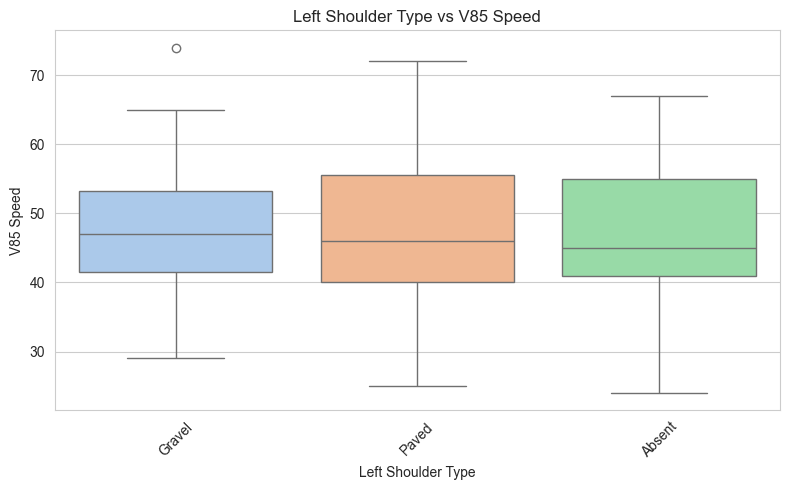

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Left Shoulder Type"], y=df["V85 Speed"], palette="pastel")
plt.xticks(rotation=45)
plt.title("Left Shoulder Type vs V85 Speed")
plt.xlabel("Left Shoulder Type")
plt.ylabel("V85 Speed")
plt.tight_layout()
plt.show()

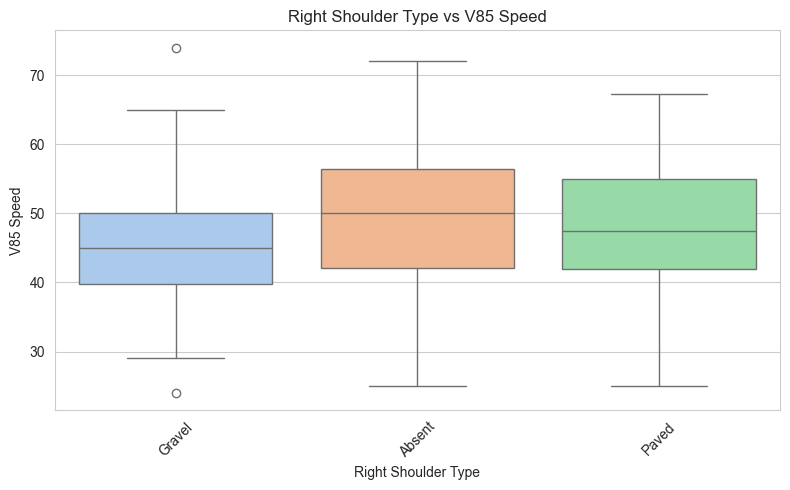

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Right Shoulder Type"], y=df["V85 Speed"], palette="pastel")
plt.xticks(rotation=45)
plt.title("Right Shoulder Type vs V85 Speed")
plt.xlabel("Right Shoulder Type")
plt.ylabel("V85 Speed")
plt.tight_layout()
plt.show()

CHECKING SKEWNESS OF NUMERICAL VARIABLES

In [32]:
df[num_cols].skew()

V85 Speed              -0.006374
Gradient                0.381686
Carriageway Width      -0.339377
Left Shoulder Width    -0.098318
Right Shoulder Width   -0.135425
Curvature               1.690216
dtype: float64

In [33]:
skew_table = pd.DataFrame({
    "Variable": num_cols,
    "Skewness": df[num_cols].skew().values
})

skew_table

,Variable,Skewness
0,V85 Speed,-0.006374
1,Gradient,0.381686
2,Carriageway Width,-0.339377
3,Left Shoulder Width,-0.098318
4,Right Shoulder Width,-0.135425
5,Curvature,1.690216


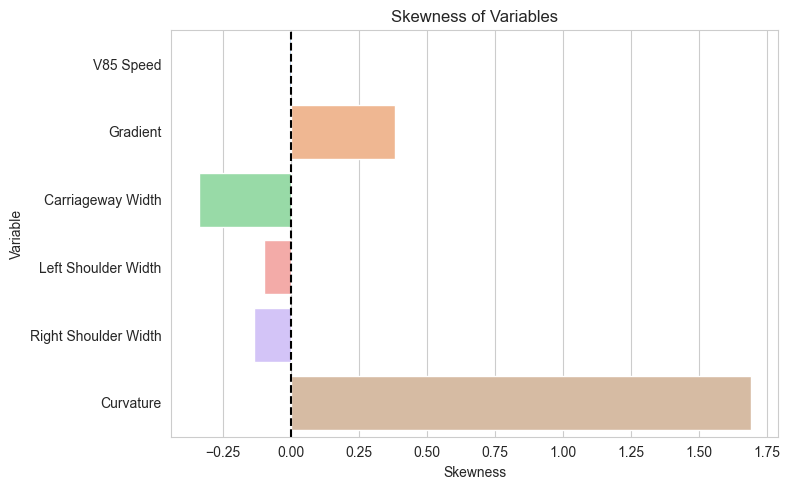

In [34]:
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(x=skew_table["Skewness"], y=skew_table["Variable"], palette="pastel")

plt.axvline(0, color="black", linestyle="--")
plt.title("Skewness of Variables")
plt.xlabel("Skewness")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

COMPUTE PEARSON CORRELATION MATRIX

In [35]:
corr_matrix = df[num_cols].corr()
corr_matrix

,V85 Speed,Gradient,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Curvature
V85 Speed,1.000000,-0.014513,0.081495,0.025410,-0.039360,-0.663924
Gradient,-0.014513,1.000000,-0.177301,-0.167458,-0.176552,-0.001361
Carriageway Width,0.081495,-0.177301,1.000000,0.032165,-0.207924,-0.075322
Left Shoulder Width,0.025410,-0.167458,0.032165,1.000000,0.333377,-0.172550
Right Shoulder Width,-0.039360,-0.176552,-0.207924,0.333377,1.000000,-0.000195
Curvature,-0.663924,-0.001361,-0.075322,-0.172550,-0.000195,1.000000


CORRELATION HEATMAP

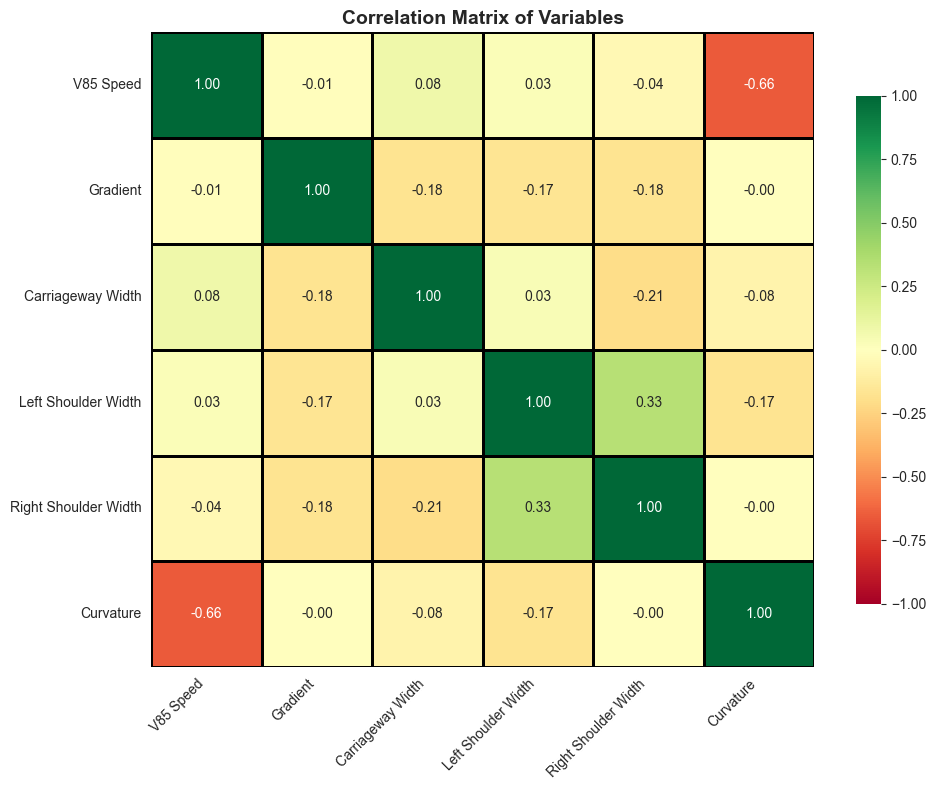

In [36]:
sns.set_style("white")

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlGn",        # your preferred colors
    vmin=-1, vmax=1,
    center=0,
    fmt=".2f",
    linewidths=0.8,
    linecolor="black",    # darker grid lines
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Variables", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

DEFINE PREDICTOR VARAIBLES

In [37]:
predictor_cols = [
    "Curvature",
    "Gradient",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]

COMBINED SCATTER PLOTS WITH TREND LINE

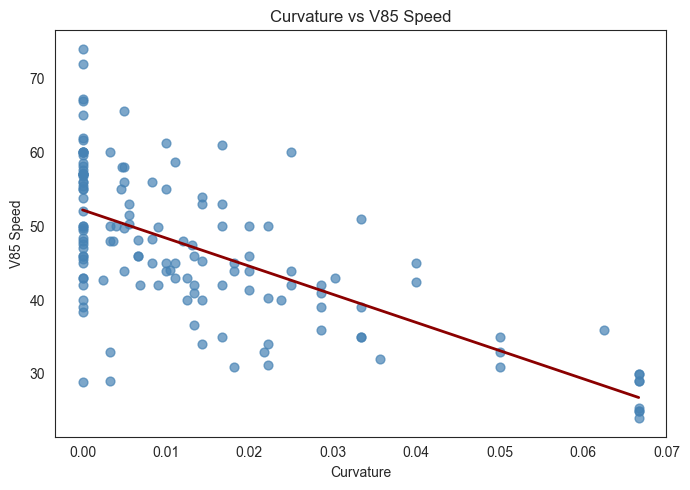

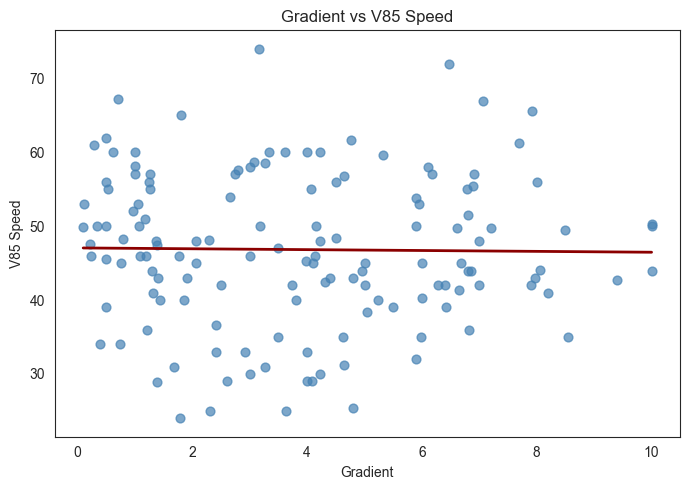

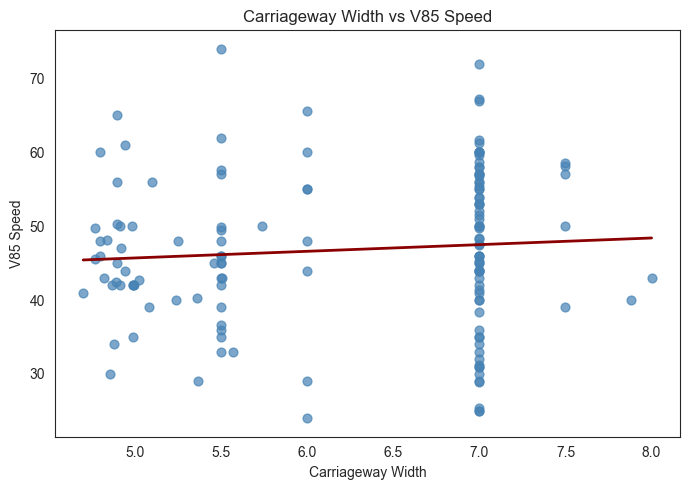

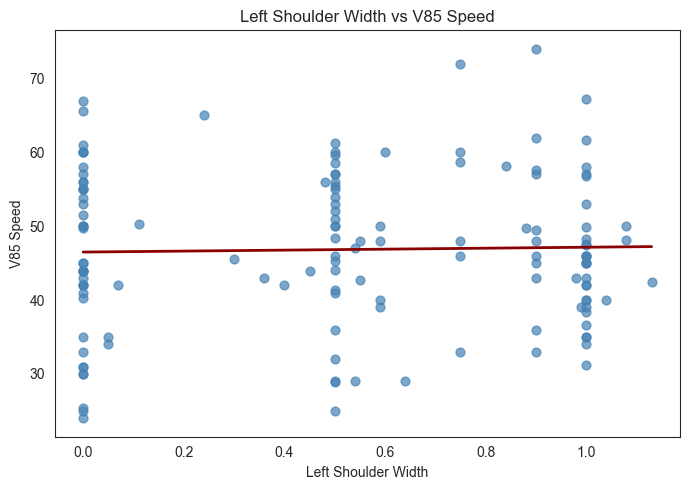

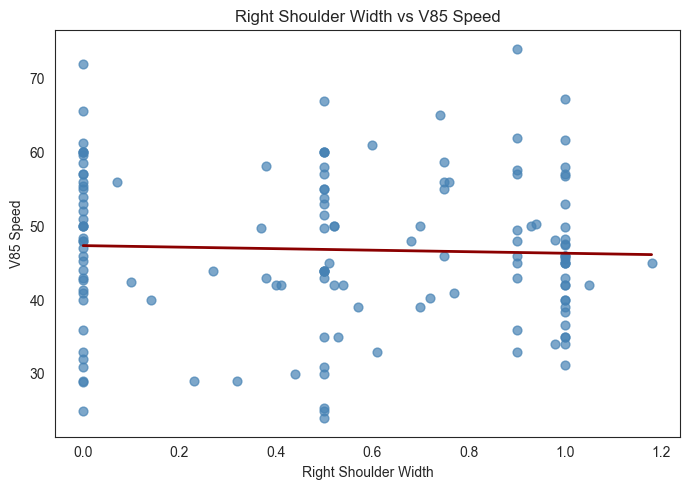

In [38]:
sns.set_style("white")

for col in predictor_cols:
    plt.figure(figsize=(7,5))   # same size for each plot

    sns.regplot(
        x=df[col],
        y=df["V85 Speed"],
        scatter_kws={"s":40, "color":"steelblue", "alpha":0.7},
        line_kws={"color":"darkred", "linewidth":2},
        ci=None   # no shaded region
    )

    plt.title(f"{col} vs V85 Speed")
    plt.xlabel(col)
    plt.ylabel("V85 Speed")

    plt.tight_layout()
    plt.show()

ENCODING CATEGORICAL VARIABLES

In [39]:
df_encoded = pd.get_dummies(
    df,
    columns=["Left Shoulder Type", "Right Shoulder Type"],
    drop_first=True   # IMPORTANT to avoid dummy trap
)

DEFINE VARIABLES FOR VIF

In [40]:
X_vif = df_encoded[[
    "Curvature",
    "Gradient",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
] + [col for col in df_encoded.columns if "Shoulder Type" in col]]

COMPUTE VIF

In [41]:
X_vif = X_vif.astype(float)

In [42]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data

,Feature,VIF
0,Curvature,1.769694
1,Gradient,3.360298
2,Carriageway Width,8.702491
3,Left Shoulder Width,12.392538
4,Right Shoulder Width,13.129134
5,Left Shoulder Type_Gravel,8.724549
6,Left Shoulder Type_Paved,7.147221
7,Right Shoulder Type_Gravel,7.881025
8,Right Shoulder Type_Paved,8.890833


VIF WITH NUMERICAL VARIABLES ONLY

In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Only numerical variables
X_vif_num = df[[
    "Curvature",
    "Gradient",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]]

# Ensure numeric
X_vif_num = X_vif_num.astype(float)

# Compute VIF
vif_data_num = pd.DataFrame()
vif_data_num["Feature"] = X_vif_num.columns
vif_data_num["VIF"] = [variance_inflation_factor(X_vif_num.values, i) for i in range(X_vif_num.shape[1])]

vif_data_num

,Feature,VIF
0,Curvature,1.622419
1,Gradient,2.942274
2,Carriageway Width,6.112834
3,Left Shoulder Width,3.110915
4,Right Shoulder Width,2.916168


CREATE AVERAGE SHOULDER WIDTH

In [44]:
df["Avg Shoulder Width"] = (
    df["Left Shoulder Width"] + df["Right Shoulder Width"]
) / 2

VIF WITH AVG SHOULDER WIDTH

In [45]:
X_vif_avg = df[[
    "Curvature",
    "Gradient",
    "Carriageway Width",
    "Avg Shoulder Width"
]].astype(float)

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_avg = pd.DataFrame()
vif_avg["Feature"] = X_vif_avg.columns
vif_avg["VIF"] = [
    variance_inflation_factor(X_vif_avg.values, i)
    for i in range(X_vif_avg.shape[1])
]

vif_avg

,Feature,VIF
0,Curvature,1.574643
1,Gradient,2.939233
2,Carriageway Width,6.051826
3,Avg Shoulder Width,3.238279


Define features and target

In [46]:
features = [
    "Curvature",
    "Gradient",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]

target = "V85 Speed"

X = df[features]
y = df[target]

STANDARDIZE FEATURES AND DISPLAY

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first rows
X_scaled.head()

,Curvature,Gradient,Carriageway Width,Left Shoulder Width,Right Shoulder Width
0,-0.783924,-1.014691,-0.811857,0.969287,0.9636
1,0.425041,-0.371273,-0.811857,0.969287,0.9636
2,-0.783924,1.597976,-0.811857,0.969287,0.9636
3,-0.783924,-0.702731,-0.811857,0.969287,0.9636
4,2.691852,-1.038088,-0.811857,0.969287,0.9636


CHECK MEAN AND SD

In [48]:
print("Mean:\n", X_scaled.mean())
print("\nStd Dev:\n", X_scaled.std())

Mean:
 Curvature               6.344132e-17
Gradient                3.362390e-16
Carriageway Width      -2.030122e-16
Left Shoulder Width    -5.075305e-17
Right Shoulder Width   -3.298948e-16
dtype: float64

Std Dev:
 Curvature               1.003591
Gradient                1.003591
Carriageway Width       1.003591
Left Shoulder Width     1.003591
Right Shoulder Width    1.003591
dtype: float64


TRAIN TEST SPLIT (80/20)

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

LINEAR REGRESSION MODEL

In [50]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
y_pred = lr_model.predict(X_test)

In [52]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: 0.3800138109573775
RMSE: 6.268103844596943
MAE: 4.856288067750256


In [53]:
coefficients = pd.DataFrame({
    "Variable": features,
    "Coefficient": lr_model.coef_
})

coefficients

,Variable,Coefficient
0,Curvature,-7.295365
1,Gradient,-0.592595
2,Carriageway Width,0.278330
3,Left Shoulder Width,-0.973563
4,Right Shoulder Width,-0.364049


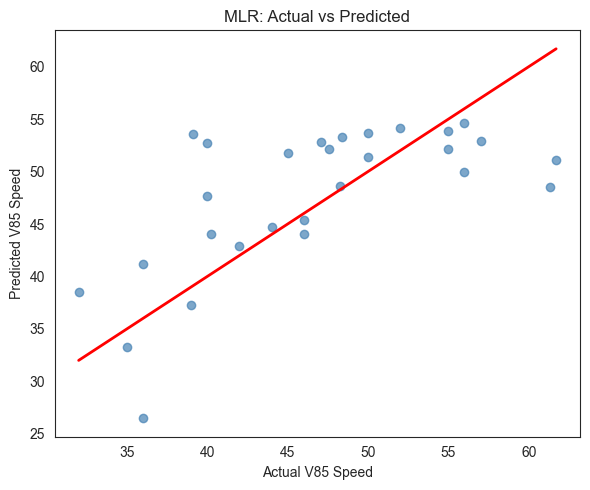

In [54]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred, color="steelblue", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("MLR: Actual vs Predicted")

plt.tight_layout()
plt.show()

RANDOM FOREST

In [55]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_model = RandomForestRegressor(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

In [56]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("R2:", r2_rf)
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)

R2: 0.09060659845531971
RMSE: 7.591386000640094
MAE: 6.100357142857151


In [57]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
0,Curvature,0.555558
1,Gradient,0.245373
4,Right Shoulder Width,0.074914
3,Left Shoulder Width,0.064406
2,Carriageway Width,0.059750


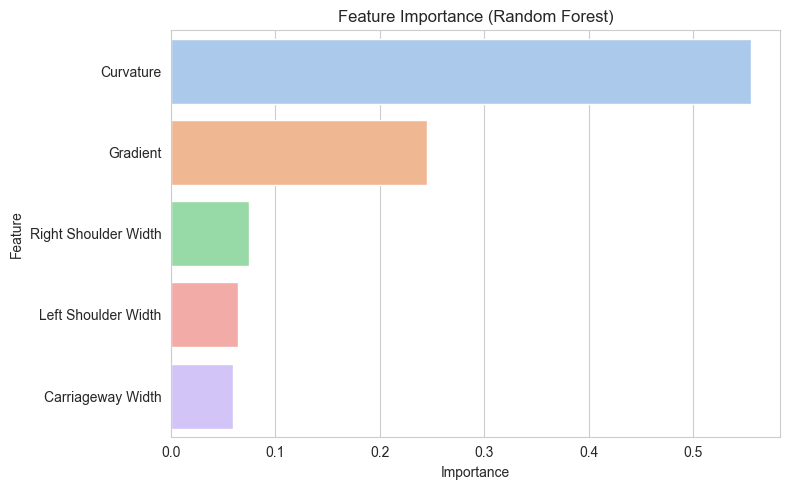

In [58]:
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance, palette="pastel")

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

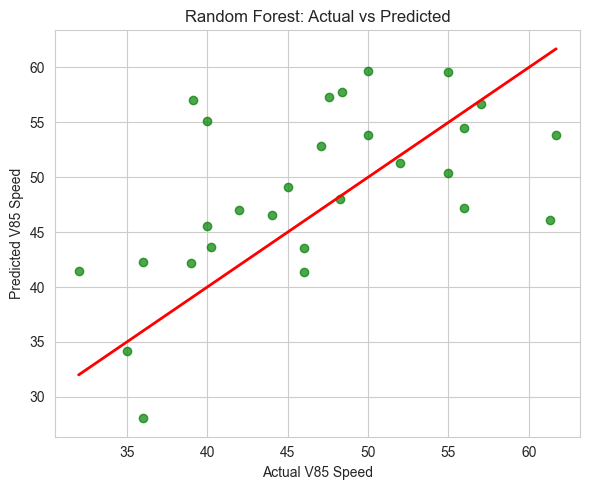

In [59]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_rf, color="green", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Random Forest: Actual vs Predicted")

plt.tight_layout()
plt.show()

SUPPORT VECTOR REGRESSOR

In [60]:
from sklearn.svm import SVR

# Initialize model
svr_model = SVR()

# Train model
svr_model.fit(X_train, y_train)

# Predict
y_pred_svr = svr_model.predict(X_test)

In [61]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("R2:", r2_svr)
print("RMSE:", rmse_svr)
print("MAE:", mae_svr)

R2: 0.36163084879552965
RMSE: 6.360351557820187
MAE: 4.845674724730898


ACTUAL VS PREDICTED

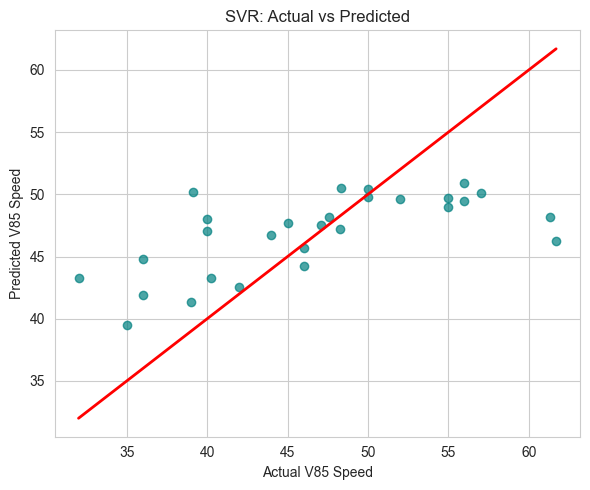

In [62]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_svr, color="teal", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("SVR: Actual vs Predicted")

plt.tight_layout()
plt.show()

XGBOOST MODEL

In [63]:
from xgboost import XGBRegressor

# Initialize model
xgb_model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

# Train model
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

In [64]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("R2:", r2_xgb)
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)

R2: -0.20428356662924219
RMSE: 8.735938245834744
MAE: 6.92085178920201


In [65]:
xgb_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance

,Feature,Importance
0,Curvature,0.439845
4,Right Shoulder Width,0.197977
1,Gradient,0.123229
2,Carriageway Width,0.122794
3,Left Shoulder Width,0.116156


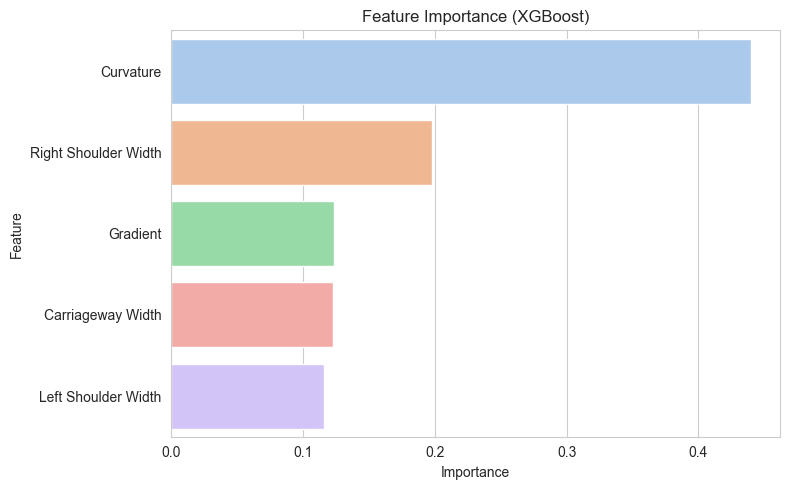

In [66]:
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=xgb_importance, palette="pastel")

plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

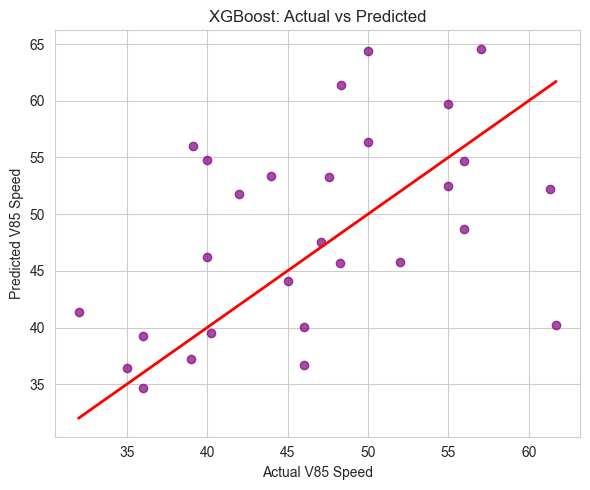

In [67]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_xgb, color="purple", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("XGBoost: Actual vs Predicted")

plt.tight_layout()
plt.show()

ANN MODEL

In [68]:
from sklearn.neural_network import MLPRegressor

# Initialize model
ann_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=5000,
    random_state=42
)

# Train model
ann_model.fit(X_train, y_train)

# Predict
y_pred_ann = ann_model.predict(X_test)

In [69]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_ann = r2_score(y_test, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
mae_ann = mean_absolute_error(y_test, y_pred_ann)

print("R2:", r2_ann)
print("RMSE:", rmse_ann)
print("MAE:", mae_ann)

R2: -1.2862566737091776
RMSE: 12.036706430007133
MAE: 9.754779425746138


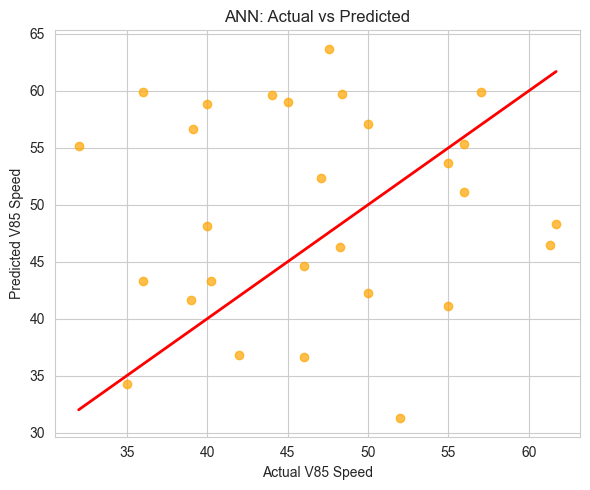

In [70]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_ann, color="orange", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("ANN: Actual vs Predicted")

plt.tight_layout()
plt.show()

COMPARISON OF MODEL PERFORMANCES

In [71]:
base_model_results = pd.DataFrame({
    "Model": ["MLR", "Random Forest", "SVR", "XGBoost", "ANN"],
    "R2": [r2, r2_rf, r2_svr, r2_xgb, r2_ann],
    "RMSE": [rmse, rmse_rf, rmse_svr, rmse_xgb, rmse_ann],
    "MAE": [mae, mae_rf, mae_svr, mae_xgb, mae_ann]
})

base_model_results.sort_values(by="R2", ascending=False)

,Model,R2,RMSE,MAE
0,MLR,0.380014,6.268104,4.856288
2,SVR,0.361631,6.360352,4.845675
1,Random Forest,0.090607,7.591386,6.100357
3,XGBoost,-0.204284,8.735938,6.920852
4,ANN,-1.286257,12.036706,9.754779


HYPERPARAMETER TUNING FOR RF

Define Parameter Grid for RF

In [72]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

Perform Randomized Search for RF

In [73]:
rf_tuned = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid_rf,
    n_iter=20,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here..

Best Parameters

In [74]:
rf_tuned.best_params_

{'n_estimators': 100,
 'min_samples_split': 10,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 20}

Predict Using Tuned RF

In [75]:
y_pred_rf_tuned = rf_tuned.best_estimator_.predict(X_test)

Evaluate Tuned RF

In [76]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)

print("R2:", r2_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("MAE:", mae_rf_tuned)

R2: 0.33891238645976385
RMSE: 6.472539140112045
MAE: 4.85847399156691


Recalculate Feature Importance

In [77]:
importance_tuned = pd.DataFrame({
    "Feature": features,
    "Importance": rf_tuned.best_estimator_.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_tuned

,Feature,Importance
0,Curvature,0.565722
1,Gradient,0.243260
4,Right Shoulder Width,0.069070
2,Carriageway Width,0.062399
3,Left Shoulder Width,0.059549


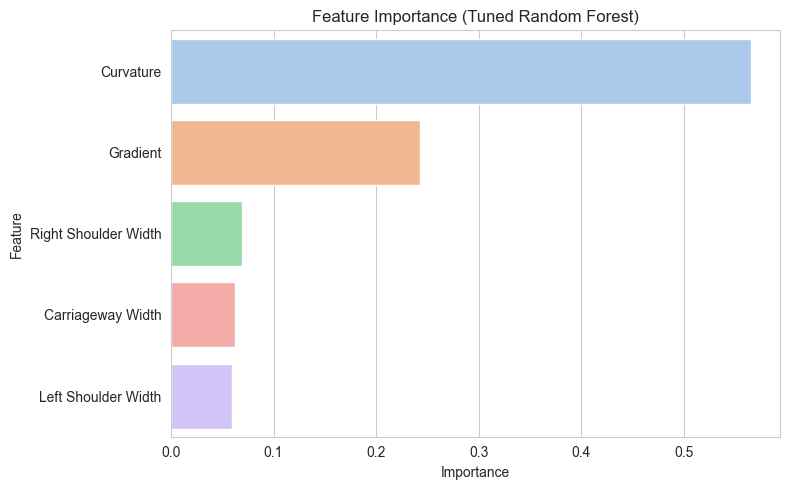

In [78]:
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_tuned,
    palette="pastel"
)

plt.title("Feature Importance (Tuned Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

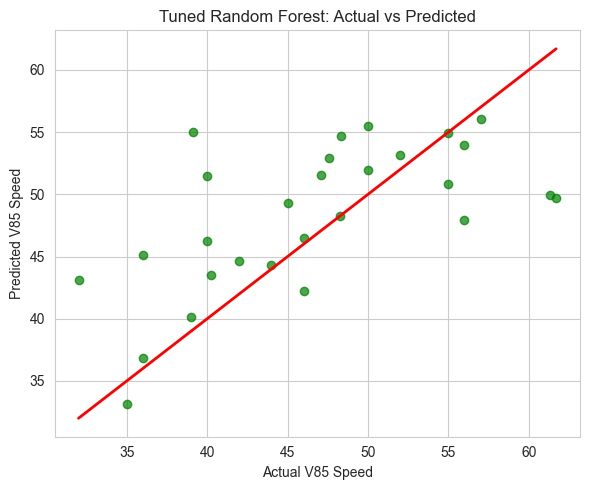

In [79]:
plt.figure(figsize=(6,5))

plt.scatter(
    y_test,
    y_pred_rf_tuned,
    color="green",
    alpha=0.7
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned Random Forest: Actual vs Predicted")

plt.tight_layout()
plt.show()

TUNED SVR

In [80]:
from sklearn.model_selection import GridSearchCV

param_grid_svr = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5, 1],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto"]
}

In [81]:
svr_tuned = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_svr,
    cv=5,
    verbose=1,
    n_jobs=-1
)

svr_tuned.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'epsilon': [0.01, 0.1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

In [82]:
svr_tuned.best_params_

{'C': 1, 'epsilon': 1, 'gamma': 'scale', 'kernel': 'linear'}

In [83]:
y_pred_svr_tuned = svr_tuned.best_estimator_.predict(X_test)

In [84]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_svr_tuned = r2_score(y_test, y_pred_svr_tuned)
rmse_svr_tuned = np.sqrt(mean_squared_error(y_test, y_pred_svr_tuned))
mae_svr_tuned = mean_absolute_error(y_test, y_pred_svr_tuned)

print("R2:", r2_svr_tuned)
print("RMSE:", rmse_svr_tuned)
print("MAE:", mae_svr_tuned)

R2: 0.3443424552447665
RMSE: 6.445902124414748
MAE: 5.013198642861367


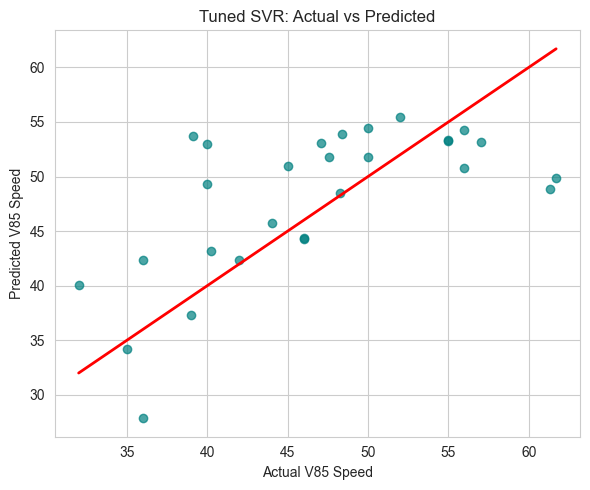

In [85]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_svr_tuned, color="teal", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned SVR: Actual vs Predicted")

plt.tight_layout()
plt.show()

TUNED XGBOOST

In [86]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [87]:
from xgboost import XGBRegressor

xgb_tuned = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_distributions=param_grid_xgb,
    n_iter=20,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [88]:
xgb_tuned.best_params_

{'subsample': 0.7,
 'n_estimators': 300,
 'max_depth': 3,
 'learning_rate': 0.01,
 'colsample_bytree': 0.7}

In [89]:
y_pred_xgb_tuned = xgb_tuned.best_estimator_.predict(X_test)

In [90]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)

print("R2:", r2_xgb_tuned)
print("RMSE:", rmse_xgb_tuned)
print("MAE:", mae_xgb_tuned)

R2: 0.21806073357699274
RMSE: 7.039335857563272
MAE: 5.265870176042831


In [91]:
xgb_importance_tuned = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_tuned.best_estimator_.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance_tuned

,Feature,Importance
0,Curvature,0.469318
1,Gradient,0.171633
4,Right Shoulder Width,0.150101
2,Carriageway Width,0.104676
3,Left Shoulder Width,0.104272


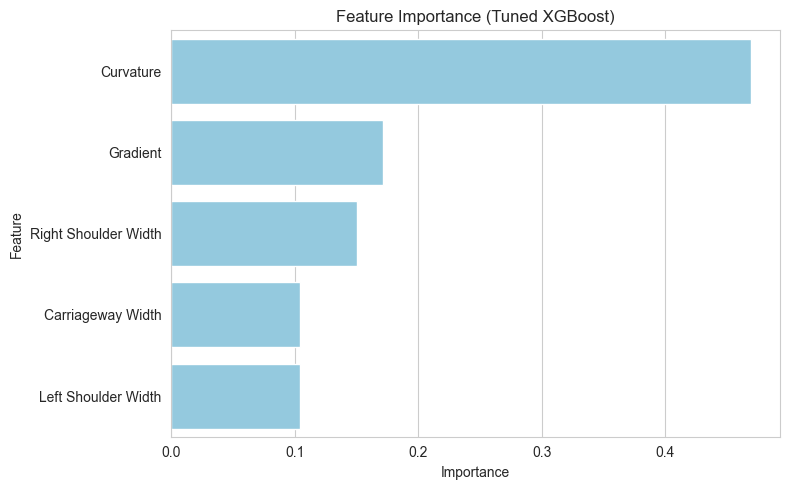

In [92]:
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=xgb_importance_tuned,
    color="skyblue"
)

plt.title("Feature Importance (Tuned XGBoost)")
plt.tight_layout()
plt.show()

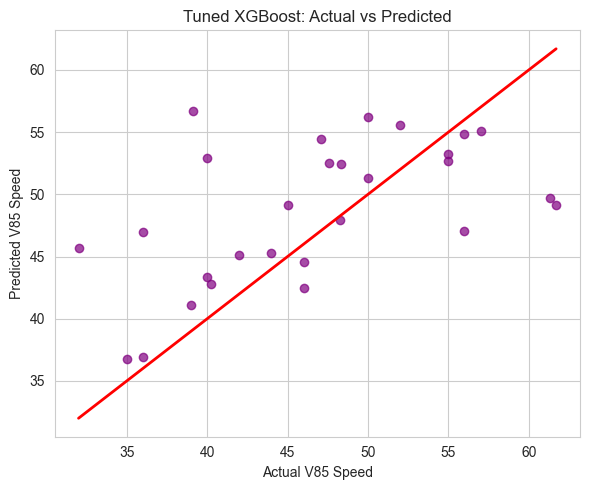

In [93]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_xgb_tuned, color="purple", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned XGBoost: Actual vs Predicted")

plt.tight_layout()
plt.show()

TUNED ANN

In [94]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPRegressor

param_grid_ann = {
    "hidden_layer_sizes": [(32,), (64,), (32, 16), (64, 32)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "solver": ["adam"],
    "max_iter": [3000, 5000]
}

In [95]:
ann_tuned = RandomizedSearchCV(
    estimator=MLPRegressor(random_state=42),
    param_distributions=param_grid_ann,
    n_iter=20,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

ann_tuned.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPRegressor(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(32,), (64,), ...], 'learning_rate_init': [0.001, 0.01], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be

In [96]:
ann_tuned.best_params_

{'solver': 'adam',
 'max_iter': 3000,
 'learning_rate_init': 0.001,
 'hidden_layer_sizes': (32,),
 'alpha': 0.01,
 'activation': 'tanh'}

In [97]:
y_pred_ann_tuned = ann_tuned.best_estimator_.predict(X_test)

In [98]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_ann_tuned = r2_score(y_test, y_pred_ann_tuned)
rmse_ann_tuned = np.sqrt(mean_squared_error(y_test, y_pred_ann_tuned))
mae_ann_tuned = mean_absolute_error(y_test, y_pred_ann_tuned)

print("R2:", r2_ann_tuned)
print("RMSE:", rmse_ann_tuned)
print("MAE:", mae_ann_tuned)

R2: 0.4163230282387217
RMSE: 6.081790485524929
MAE: 4.888091055986173


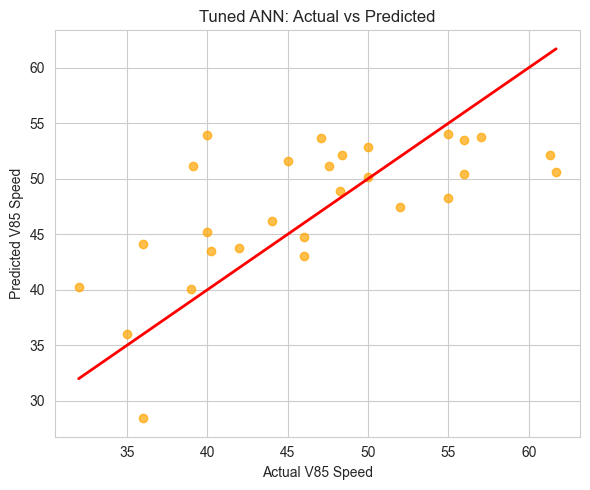

In [99]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_ann_tuned, color="orange", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Tuned ANN: Actual vs Predicted")

plt.tight_layout()
plt.show()

BASE MODEL COMPARISON

In [100]:
base_models = pd.DataFrame({
    "Model": ["MLR", "SVR", "Random Forest", "XGBoost", "ANN"],
    "R2": [r2, r2_svr, r2_rf, r2_xgb, r2_ann],
    "RMSE": [rmse, rmse_svr, rmse_rf, rmse_xgb, rmse_ann],
    "MAE": [mae, mae_svr, mae_rf, mae_xgb, mae_ann]
})

base_models = base_models.sort_values(by="R2", ascending=False)
base_models

,Model,R2,RMSE,MAE
0,MLR,0.380014,6.268104,4.856288
1,SVR,0.361631,6.360352,4.845675
2,Random Forest,0.090607,7.591386,6.100357
3,XGBoost,-0.204284,8.735938,6.920852
4,ANN,-1.286257,12.036706,9.754779


TUNED MODEL COMPARISON

In [101]:
tuned_models = pd.DataFrame({
    "Model": ["Tuned RF", "Tuned SVR", "Tuned XGBoost", "Tuned ANN"],
    "R2": [r2_rf_tuned, r2_svr_tuned, r2_xgb_tuned, r2_ann_tuned],
    "RMSE": [rmse_rf_tuned, rmse_svr_tuned, rmse_xgb_tuned, rmse_ann_tuned],
    "MAE": [mae_rf_tuned, mae_svr_tuned, mae_xgb_tuned, mae_ann_tuned]
})

tuned_models = tuned_models.sort_values(by="R2", ascending=False)
tuned_models

,Model,R2,RMSE,MAE
3,Tuned ANN,0.416323,6.081790,4.888091
1,Tuned SVR,0.344342,6.445902,5.013199
0,Tuned RF,0.338912,6.472539,4.858474
2,Tuned XGBoost,0.218061,7.039336,5.265870


In [102]:
final_comparison = pd.DataFrame({
    "Model": ["MLR", "SVR", "RF", "XGBoost", "ANN",
              "Tuned RF", "Tuned SVR", "Tuned XGBoost", "Tuned ANN"],

    "R2": [r2, r2_svr, r2_rf, r2_xgb, r2_ann,
           r2_rf_tuned, r2_svr_tuned, r2_xgb_tuned, r2_ann_tuned],

    "RMSE": [rmse, rmse_svr, rmse_rf, rmse_xgb, rmse_ann,
             rmse_rf_tuned, rmse_svr_tuned, rmse_xgb_tuned, rmse_ann_tuned],

    "MAE": [mae, mae_svr, mae_rf, mae_xgb, mae_ann,
            mae_rf_tuned, mae_svr_tuned, mae_xgb_tuned, mae_ann_tuned]
})

final_comparison = final_comparison.sort_values(by="R2", ascending=False)
final_comparison

,Model,R2,RMSE,MAE
8,Tuned ANN,0.416323,6.081790,4.888091
0,MLR,0.380014,6.268104,4.856288
1,SVR,0.361631,6.360352,4.845675
6,Tuned SVR,0.344342,6.445902,5.013199
5,Tuned RF,0.338912,6.472539,4.858474
7,Tuned XGBoost,0.218061,7.039336,5.265870
2,RF,0.090607,7.591386,6.100357
3,XGBoost,-0.204284,8.735938,6.920852
4,ANN,-1.286257,12.036706,9.754779


CROSS VALIDATIONS FOR TUNED ANN AND MLR MODELS

Define models for cross-validation

In [103]:
model_ann = ann_tuned.best_estimator_
model_mlr = lr_model

Perform 5 fold Cross Validation

In [104]:
from sklearn.model_selection import cross_val_score
import numpy as np

# ANN
cv_r2_ann = cross_val_score(model_ann, X_scaled, y, cv=5, scoring="r2")
cv_rmse_ann = np.sqrt(-cross_val_score(model_ann, X_scaled, y, cv=5, scoring="neg_mean_squared_error"))
cv_mae_ann = -cross_val_score(model_ann, X_scaled, y, cv=5, scoring="neg_mean_absolute_error")

# MLR
cv_r2_mlr = cross_val_score(model_mlr, X_scaled, y, cv=5, scoring="r2")
cv_rmse_mlr = np.sqrt(-cross_val_score(model_mlr, X_scaled, y, cv=5, scoring="neg_mean_squared_error"))
cv_mae_mlr = -cross_val_score(model_mlr, X_scaled, y, cv=5, scoring="neg_mean_absolute_error")

Print Results

In [105]:
print("===== ANN CV Results =====")
print("R2:", cv_r2_ann)
print("Mean R2:", np.mean(cv_r2_ann))
print("RMSE:", cv_rmse_ann)
print("Mean RMSE:", np.mean(cv_rmse_ann))
print("MAE:", cv_mae_ann)
print("Mean MAE:", np.mean(cv_mae_ann))

print("\n===== MLR CV Results =====")
print("R2:", cv_r2_mlr)
print("Mean R2:", np.mean(cv_r2_mlr))
print("RMSE:", cv_rmse_mlr)
print("Mean RMSE:", np.mean(cv_rmse_mlr))
print("MAE:", cv_mae_mlr)
print("Mean MAE:", np.mean(cv_mae_mlr))

===== ANN CV Results =====
R2: [0.23490375 0.23127877 0.37468002 0.59828775 0.06117758]
Mean R2: 0.30006557562905756
RMSE: [ 9.0448909   6.82860834  7.44732782  7.69439733 10.60996051]
Mean RMSE: 8.325036981332186
MAE: [7.36218425 5.46672577 5.98128024 5.93252858 8.30473341]
Mean MAE: 6.609490449456162

===== MLR CV Results =====
R2: [ 0.34805085  0.27281188  0.44551747  0.6449707  -0.00463   ]
Mean R2: 0.3413441794757786
RMSE: [ 8.34934023  6.64157613  7.01282905  7.23351137 10.97552023]
Mean RMSE: 8.042555400144145
MAE: [6.85609916 5.3301503  5.77065741 5.17197119 8.55823384]
Mean MAE: 6.337422379950212


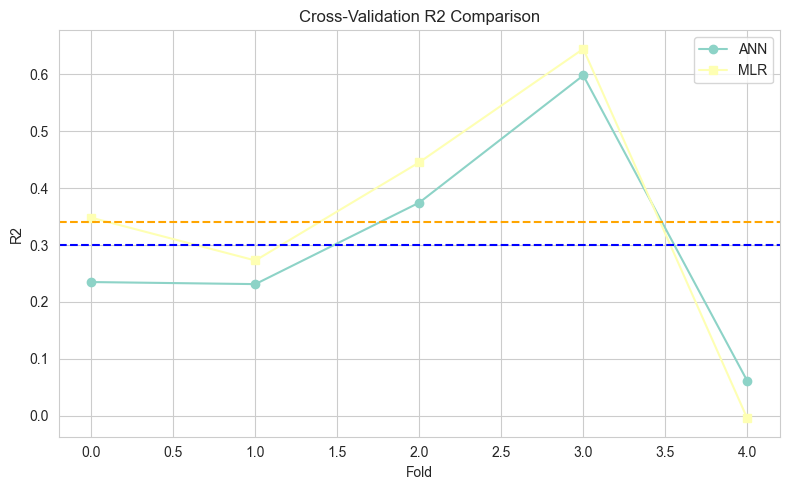

In [106]:
plt.figure(figsize=(8,5))

plt.plot(cv_r2_ann, marker='o', label="ANN")
plt.plot(cv_r2_mlr, marker='s', label="MLR")

plt.axhline(np.mean(cv_r2_ann), color='blue', linestyle='--')
plt.axhline(np.mean(cv_r2_mlr), color='orange', linestyle='--')

plt.title("Cross-Validation R2 Comparison")
plt.xlabel("Fold")
plt.ylabel("R2")
plt.legend()

plt.tight_layout()
plt.show()

In [107]:
cv_results = pd.DataFrame({
    "Model": ["ANN (Tuned)", "MLR"],

    "Mean R2": [np.mean(cv_r2_ann), np.mean(cv_r2_mlr)],
    "Mean RMSE": [np.mean(cv_rmse_ann), np.mean(cv_rmse_mlr)],
    "Mean MAE": [np.mean(cv_mae_ann), np.mean(cv_mae_mlr)]
})

cv_results

,Model,Mean R2,Mean RMSE,Mean MAE
0,ANN (Tuned),0.300066,8.325037,6.609490
1,MLR,0.341344,8.042555,6.337422


AVERAGE SHOULDER WIDTH

In [163]:
df["Avg Shoulder Width"] = (
    df["Left Shoulder Width"] + df["Right Shoulder Width"]
) / 2

In [164]:
features = [
    "Curvature",
    "Gradient",
    "Carriageway Width",
    "Avg Shoulder Width"
]

target = "V85 Speed"

X = df[features]
y = df[target]

In [165]:
df.columns

Index(['SN', 'V85 Speed', 'Gradient', 'Carriageway Width',
       'Left Shoulder Width', 'Left Shoulder Type', 'Right Shoulder Width',
       'Right Shoulder Type', 'Curvature', 'Avg Shoulder Width'],
      dtype='str')

In [166]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [167]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [168]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [169]:
models = {
    "MLR": LinearRegression(),
    "RF": RandomForestRegressor(random_state=42),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(objective="reg:squarederror", random_state=42),
    "ANN": MLPRegressor(hidden_layer_sizes=(64,32), max_iter=5000, random_state=42)
}

In [170]:
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

In [171]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

results = []

for name, y_pred in predictions.items():
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append([name, r2, rmse, mae])

results_df = pd.DataFrame(results, columns=["Model", "R2", "RMSE", "MAE"])
results_df.sort_values(by="R2", ascending=False)

,Model,R2,RMSE,MAE
2,SVR,0.404515,6.143003,4.705828
0,MLR,0.368183,6.327626,4.911160
1,RF,0.019101,7.884193,6.488554
3,XGBoost,-0.388936,9.381804,7.586856
4,ANN,-0.599838,10.068927,7.741079


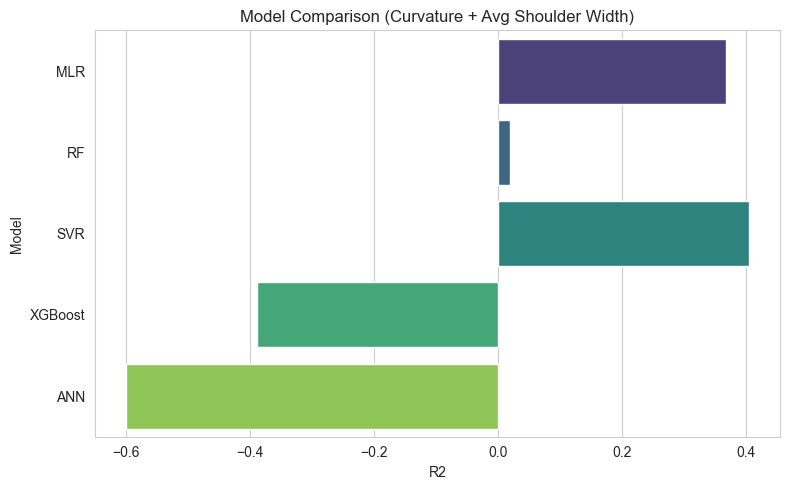

In [172]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

sns.barplot(
    x="R2",
    y="Model",
    data=results_df,
    palette="viridis"
)

plt.title("Model Comparison (Curvature + Avg Shoulder Width)")
plt.tight_layout()
plt.show()

In [173]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_tuned = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_rf,
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_tuned.fit(X_train, y_train)
y_pred_rf_tuned = rf_tuned.best_estimator_.predict(X_test)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [174]:
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)

print("Best RF Params:", rf_tuned.best_params_)
print("R2:", r2_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("MAE:", mae_rf_tuned)

Best RF Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
R2: 0.3082442539944301
RMSE: 6.620969128754691
MAE: 4.9815221414215145


In [175]:
from sklearn.svm import SVR

param_svr = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

svr_tuned = GridSearchCV(
    estimator=SVR(),
    param_grid=param_svr,
    cv=5,
    n_jobs=-1,
    verbose=1
)

svr_tuned.fit(X_train, y_train)
y_pred_svr_tuned = svr_tuned.best_estimator_.predict(X_test)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [176]:
r2_svr_tuned = r2_score(y_test, y_pred_svr_tuned)
rmse_svr_tuned = np.sqrt(mean_squared_error(y_test, y_pred_svr_tuned))
mae_svr_tuned = mean_absolute_error(y_test, y_pred_svr_tuned)

print("Best SVR Params:", svr_tuned.best_params_)
print("R2:", r2_svr_tuned)
print("RMSE:", rmse_svr_tuned)
print("MAE:", mae_svr_tuned)

Best SVR Params: {'C': 100, 'epsilon': 0.5, 'gamma': 'scale', 'kernel': 'linear'}
R2: 0.2891852433196387
RMSE: 6.711558700179546
MAE: 5.167031474279398


In [177]:
from xgboost import XGBRegressor

param_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_tuned = GridSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),
    param_grid=param_xgb,
    cv=5,
    n_jobs=-1,
    verbose=1
)

xgb_tuned.fit(X_train, y_train)
y_pred_xgb_tuned = xgb_tuned.best_estimator_.predict(X_test)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [178]:
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)

print("Best XGBoost Params:", xgb_tuned.best_params_)
print("R2:", r2_xgb_tuned)
print("RMSE:", rmse_xgb_tuned)
print("MAE:", mae_xgb_tuned)

Best XGBoost Params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
R2: 0.2776820178555429
RMSE: 6.765647842941681
MAE: 5.189674731663296


In [179]:
from sklearn.neural_network import MLPRegressor

param_ann = {
    "hidden_layer_sizes": [(32,), (64,), (32, 16), (64, 32)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "solver": ["adam"],
    "max_iter": [3000, 5000]
}

ann_tuned = GridSearchCV(
    estimator=MLPRegressor(random_state=42),
    param_grid=param_ann,
    cv=5,
    n_jobs=-1,
    verbose=1
)

ann_tuned.fit(X_train, y_train)
y_pred_ann_tuned = ann_tuned.best_estimator_.predict(X_test)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


In [180]:
r2_ann_tuned = r2_score(y_test, y_pred_ann_tuned)
rmse_ann_tuned = np.sqrt(mean_squared_error(y_test, y_pred_ann_tuned))
mae_ann_tuned = mean_absolute_error(y_test, y_pred_ann_tuned)

print("Best ANN Params:", ann_tuned.best_params_)
print("R2:", r2_ann_tuned)
print("RMSE:", rmse_ann_tuned)
print("MAE:", mae_ann_tuned)

Best ANN Params: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.001, 'max_iter': 3000, 'solver': 'adam'}
R2: 0.3614659637109935
RMSE: 6.361172915957428
MAE: 5.044952653149729


In [181]:
tuned_results = pd.DataFrame({
    "Model": ["Tuned RF", "Tuned SVR", "Tuned XGBoost", "Tuned ANN"],
    "R2": [r2_rf_tuned, r2_svr_tuned, r2_xgb_tuned, r2_ann_tuned],
    "RMSE": [rmse_rf_tuned, rmse_svr_tuned, rmse_xgb_tuned, rmse_ann_tuned],
    "MAE": [mae_rf_tuned, mae_svr_tuned, mae_xgb_tuned, mae_ann_tuned]
})

tuned_results.sort_values(by="R2", ascending=False)

,Model,R2,RMSE,MAE
3,Tuned ANN,0.361466,6.361173,5.044953
0,Tuned RF,0.308244,6.620969,4.981522
1,Tuned SVR,0.289185,6.711559,5.167031
2,Tuned XGBoost,0.277682,6.765648,5.189675


In [182]:
final_table = pd.DataFrame({
    "Model": [
        "MLR", "SVR", "Random Forest", "XGBoost", "ANN",
        "Tuned RF", "Tuned SVR", "Tuned XGBoost", "Tuned ANN"
    ],

    "Type": [
        "Base", "Base", "Base", "Base", "Base",
        "Tuned", "Tuned", "Tuned", "Tuned"
    ],

    "R2": [
        r2, r2_svr, r2_rf, r2_xgb, r2_ann,
        r2_rf_tuned, r2_svr_tuned, r2_xgb_tuned, r2_ann_tuned
    ],

    "RMSE": [
        rmse, rmse_svr, rmse_rf, rmse_xgb, rmse_ann,
        rmse_rf_tuned, rmse_svr_tuned, rmse_xgb_tuned, rmse_ann_tuned
    ],

    "MAE": [
        mae, mae_svr, mae_rf, mae_xgb, mae_ann,
        mae_rf_tuned, mae_svr_tuned, mae_xgb_tuned, mae_ann_tuned
    ]
})

final_table = final_table.sort_values(by="R2", ascending=False)
final_table.round(3)

,Model,Type,R2,RMSE,MAE
1,SVR,Base,0.362,6.360,4.846
8,Tuned ANN,Tuned,0.361,6.361,5.045
5,Tuned RF,Tuned,0.308,6.621,4.982
6,Tuned SVR,Tuned,0.289,6.712,5.167
7,Tuned XGBoost,Tuned,0.278,6.766,5.190
2,Random Forest,Base,0.091,7.591,6.100
3,XGBoost,Base,-0.204,8.736,6.921
0,MLR,Base,-0.600,10.069,7.741
4,ANN,Base,-1.286,12.037,9.755


In [183]:
# Base model table from AVG run
base_avg = results_df.copy()

# Rename model names to match your L+R naming
base_avg["Model"] = base_avg["Model"].replace({
    "RF": "Random Forest",
    "XGBoost": "XGBoost",
    "ANN": "ANN",
    "SVR": "SVR",
    "MLR": "MLR"
})

base_avg["Type"] = "Base"

# Tuned model table from AVG run
tuned_avg = tuned_results.copy()
tuned_avg["Type"] = "Tuned"

# Combine base + tuned for AVG case
final_table_avg = pd.concat([base_avg, tuned_avg], ignore_index=True)

# Reorder columns
final_table_avg = final_table_avg[["Model", "Type", "R2", "RMSE", "MAE"]]

# Sort
final_table_avg = final_table_avg.sort_values(by="R2", ascending=False)

final_table_avg.round(3)

,Model,Type,R2,RMSE,MAE
2,SVR,Base,0.405,6.143,4.706
0,MLR,Base,0.368,6.328,4.911
8,Tuned ANN,Tuned,0.361,6.361,5.045
5,Tuned RF,Tuned,0.308,6.621,4.982
6,Tuned SVR,Tuned,0.289,6.712,5.167
7,Tuned XGBoost,Tuned,0.278,6.766,5.190
1,Random Forest,Base,0.019,7.884,6.489
3,XGBoost,Base,-0.389,9.382,7.587
4,ANN,Base,-0.600,10.069,7.741


In [184]:
models_avg = {
    "MLR": LinearRegression(),
    "RF": RandomForestRegressor(random_state=42),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(objective="reg:squarederror", random_state=42),
    "ANN": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=5000, random_state=42)
}

In [185]:
predictions_avg = {}

for name, model in models_avg.items():
    model.fit(X_train, y_train)
    predictions_avg[name] = model.predict(X_test)

In [186]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

results_avg = []

for name, y_pred in predictions_avg.items():
    r2_val = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_val = mean_absolute_error(y_test, y_pred)

    results_avg.append([name, r2_val, rmse_val, mae_val])

results_df_avg = pd.DataFrame(results_avg, columns=["Model", "R2", "RMSE", "MAE"])
results_df_avg = results_df_avg.sort_values(by="R2", ascending=False)

results_df_avg.round(3)

,Model,R2,RMSE,MAE
2,SVR,0.405,6.143,4.706
0,MLR,0.368,6.328,4.911
1,RF,0.019,7.884,6.489
3,XGBoost,-0.389,9.382,7.587
4,ANN,-0.600,10.069,7.741


In [187]:
r2_mlr_avg   = results_df_avg.loc[results_df_avg["Model"]=="MLR", "R2"].values[0]
rmse_mlr_avg = results_df_avg.loc[results_df_avg["Model"]=="MLR", "RMSE"].values[0]
mae_mlr_avg  = results_df_avg.loc[results_df_avg["Model"]=="MLR", "MAE"].values[0]

r2_rf_avg   = results_df_avg.loc[results_df_avg["Model"]=="RF", "R2"].values[0]
rmse_rf_avg = results_df_avg.loc[results_df_avg["Model"]=="RF", "RMSE"].values[0]
mae_rf_avg  = results_df_avg.loc[results_df_avg["Model"]=="RF", "MAE"].values[0]

r2_svr_avg   = results_df_avg.loc[results_df_avg["Model"]=="SVR", "R2"].values[0]
rmse_svr_avg = results_df_avg.loc[results_df_avg["Model"]=="SVR", "RMSE"].values[0]
mae_svr_avg  = results_df_avg.loc[results_df_avg["Model"]=="SVR", "MAE"].values[0]

r2_xgb_avg   = results_df_avg.loc[results_df_avg["Model"]=="XGBoost", "R2"].values[0]
rmse_xgb_avg = results_df_avg.loc[results_df_avg["Model"]=="XGBoost", "RMSE"].values[0]
mae_xgb_avg  = results_df_avg.loc[results_df_avg["Model"]=="XGBoost", "MAE"].values[0]

r2_ann_avg   = results_df_avg.loc[results_df_avg["Model"]=="ANN", "R2"].values[0]
rmse_ann_avg = results_df_avg.loc[results_df_avg["Model"]=="ANN", "RMSE"].values[0]
mae_ann_avg  = results_df_avg.loc[results_df_avg["Model"]=="ANN", "MAE"].values[0]

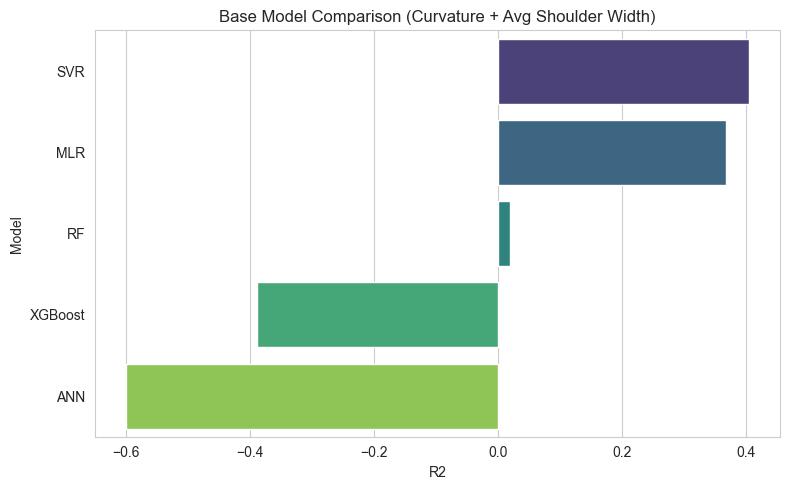

In [188]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(x="R2", y="Model", data=results_df_avg, palette="viridis")
plt.title("Base Model Comparison (Curvature + Avg Shoulder Width)")
plt.xlabel("R2")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [189]:
base_avg_table = pd.DataFrame({
    "Model": ["MLR", "SVR", "Random Forest", "XGBoost", "ANN"],
    "R2": [r2_mlr_avg, r2_svr_avg, r2_rf_avg, r2_xgb_avg, r2_ann_avg],
    "RMSE": [rmse_mlr_avg, rmse_svr_avg, rmse_rf_avg, rmse_xgb_avg, rmse_ann_avg],
    "MAE": [mae_mlr_avg, mae_svr_avg, mae_rf_avg, mae_xgb_avg, mae_ann_avg]
})

base_avg_table.sort_values(by="R2", ascending=False).round(3)

,Model,R2,RMSE,MAE
1,SVR,0.405,6.143,4.706
0,MLR,0.368,6.328,4.911
2,Random Forest,0.019,7.884,6.489
3,XGBoost,-0.389,9.382,7.587
4,ANN,-0.600,10.069,7.741


In [191]:
r2_rf_tuned_avg = r2_score(y_test, y_pred_rf_tuned)
rmse_rf_tuned_avg = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
mae_rf_tuned_avg = mean_absolute_error(y_test, y_pred_rf_tuned)

In [192]:
r2_svr_tuned_avg = r2_score(y_test, y_pred_svr_tuned)
rmse_svr_tuned_avg = np.sqrt(mean_squared_error(y_test, y_pred_svr_tuned))
mae_svr_tuned_avg = mean_absolute_error(y_test, y_pred_svr_tuned)

In [193]:
r2_xgb_tuned_avg = r2_score(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned_avg = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
mae_xgb_tuned_avg = mean_absolute_error(y_test, y_pred_xgb_tuned)

In [194]:
r2_ann_tuned_avg = r2_score(y_test, y_pred_ann_tuned)
rmse_ann_tuned_avg = np.sqrt(mean_squared_error(y_test, y_pred_ann_tuned))
mae_ann_tuned_avg = mean_absolute_error(y_test, y_pred_ann_tuned)

In [196]:
master_table = pd.DataFrame({
    "Model": [
        "MLR", "SVR", "Random Forest", "XGBoost", "ANN",
        "Tuned RF", "Tuned SVR", "Tuned XGBoost", "Tuned ANN"
    ],

    "R2 (L+R)": [
        r2, r2_svr, r2_rf, r2_xgb, r2_ann,
        r2_rf_tuned, r2_svr_tuned, r2_xgb_tuned, r2_ann_tuned
    ],
    "RMSE (L+R)": [
        rmse, rmse_svr, rmse_rf, rmse_xgb, rmse_ann,
        rmse_rf_tuned, rmse_svr_tuned, rmse_xgb_tuned, rmse_ann_tuned
    ],
    "MAE (L+R)": [
        mae, mae_svr, mae_rf, mae_xgb, mae_ann,
        mae_rf_tuned, mae_svr_tuned, mae_xgb_tuned, mae_ann_tuned
    ],

    "R2 (AVG)": [
        r2_mlr_avg, r2_svr_avg, r2_rf_avg, r2_xgb_avg, r2_ann_avg,
        r2_rf_tuned_avg, r2_svr_tuned_avg, r2_xgb_tuned_avg, r2_ann_tuned_avg
    ],
    "RMSE (AVG)": [
        rmse_mlr_avg, rmse_svr_avg, rmse_rf_avg, rmse_xgb_avg, rmse_ann_avg,
        rmse_rf_tuned_avg, rmse_svr_tuned_avg, rmse_xgb_tuned_avg, rmse_ann_tuned_avg
    ],
    "MAE (AVG)": [
        mae_mlr_avg, mae_svr_avg, mae_rf_avg, mae_xgb_avg, mae_ann_avg,
        mae_rf_tuned_avg, mae_svr_tuned_avg, mae_xgb_tuned_avg, mae_ann_tuned_avg
    ]
})

master_table.round(3)

,Model,R2 (L+R),RMSE (L+R),MAE (L+R),R2 (AVG),RMSE (AVG),MAE (AVG)
0,MLR,-0.600,10.069,7.741,0.368,6.328,4.911
1,SVR,0.362,6.360,4.846,0.405,6.143,4.706
2,Random Forest,0.091,7.591,6.100,0.019,7.884,6.489
3,XGBoost,-0.204,8.736,6.921,-0.389,9.382,7.587
4,ANN,-1.286,12.037,9.755,-0.600,10.069,7.741
5,Tuned RF,0.308,6.621,4.982,0.308,6.621,4.982
6,Tuned SVR,0.289,6.712,5.167,0.289,6.712,5.167
7,Tuned XGBoost,0.278,6.766,5.190,0.278,6.766,5.190
8,Tuned ANN,0.361,6.361,5.045,0.361,6.361,5.045


In [201]:
master_table = pd.DataFrame({
    "Model": [
        "MLR", "SVR", "RF", "XGBoost", "ANN",
        "Tuned RF", "Tuned SVR", "Tuned XGBoost", "Tuned ANN",
        "MLR", "SVR", "RF", "XGBoost", "ANN",
        "Tuned RF", "Tuned SVR", "Tuned XGBoost", "Tuned ANN"
    ],

    "R2": [
        r2, r2_svr, r2_rf, r2_xgb, r2_ann,
        r2_rf_tuned, r2_svr_tuned, r2_xgb_tuned, r2_ann_tuned,

        r2_mlr_avg, r2_svr_avg, r2_rf_avg, r2_xgb_avg, r2_ann_avg,
        r2_rf_tuned_avg, r2_svr_tuned_avg, r2_xgb_tuned_avg, r2_ann_tuned_avg
    ],

    "RMSE": [
        rmse, rmse_svr, rmse_rf, rmse_xgb, rmse_ann,
        rmse_rf_tuned, rmse_svr_tuned, rmse_xgb_tuned, rmse_ann_tuned,

        rmse_mlr_avg, rmse_svr_avg, rmse_rf_avg, rmse_xgb_avg, rmse_ann_avg,
        rmse_rf_tuned_avg, rmse_svr_tuned_avg, rmse_xgb_tuned_avg, rmse_ann_tuned_avg
    ],

    "MAE": [
        mae, mae_svr, mae_rf, mae_xgb, mae_ann,
        mae_rf_tuned, mae_svr_tuned, mae_xgb_tuned, mae_ann_tuned,

        mae_mlr_avg, mae_svr_avg, mae_rf_avg, mae_xgb_avg, mae_ann_avg,
        mae_rf_tuned_avg, mae_svr_tuned_avg, mae_xgb_tuned_avg, mae_ann_tuned_avg
    ],

    "Feature_Set": [
        "L+R", "L+R", "L+R", "L+R", "L+R",
        "L+R", "L+R", "L+R", "L+R",

        "AVG", "AVG", "AVG", "AVG", "AVG",
        "AVG", "AVG", "AVG", "AVG"
    ],

    "Type": [
        "Base", "Base", "Base", "Base", "Base",
        "Tuned", "Tuned", "Tuned", "Tuned",

        "Base", "Base", "Base", "Base", "Base",
        "Tuned", "Tuned", "Tuned", "Tuned"
    ]
})

master_table = master_table.sort_values(by="R2", ascending=False).reset_index(drop=True)
master_table = master_table.round(3)

master_table

,Model,R2,RMSE,MAE,Feature_Set,Type
0,SVR,0.405,6.143,4.706,AVG,Base
1,MLR,0.368,6.328,4.911,AVG,Base
2,SVR,0.362,6.360,4.846,L+R,Base
3,Tuned ANN,0.361,6.361,5.045,AVG,Tuned
4,Tuned ANN,0.361,6.361,5.045,L+R,Tuned
5,Tuned RF,0.308,6.621,4.982,L+R,Tuned
6,Tuned RF,0.308,6.621,4.982,AVG,Tuned
7,Tuned SVR,0.289,6.712,5.167,AVG,Tuned
8,Tuned SVR,0.289,6.712,5.167,L+R,Tuned
9,Tuned XGBoost,0.278,6.766,5.190,AVG,Tuned
